<a href="https://colab.research.google.com/github/muhammadhusnainali04-maker/CNN-Deep_Learning/blob/main/Cat_v_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle kernels pull nimapourmoradi/cats-vs-dogs-small-version

Source code downloaded to /content/cats-vs-dogs-small-version.ipynb


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout,BatchNormalization

In [ ]:
import zipfile

zip_ref = zipfile.ZipFile('/content/CAT-DOG/training_set.zip', 'r')
zip_ref.extractall('/content/CAT-DOG')
zip_ref.close()

zip_ref = zipfile.ZipFile('/content/CAT-DOG/test_set.zip', 'r')
zip_ref.extractall('/content/CAT-DOG')
zip_ref.close()

In [ ]:
# generator use to makes batches of last data
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/CAT-DOG/training_set',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)


test_ds = keras.utils.image_dataset_from_directory(
    directory='/content/CAT-DOG/test_set',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [ ]:
# Normalizatopn
def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label

train_ds=train_ds.map(process)
test_ds=test_ds.map(process)


In [ ]:
# create CNN model
model=Sequential()
model.add(Conv2D(
    32,
    kernel_size=(3,3),
    padding='valid',
    activation='relu',
    input_shape=(256,256,3)
))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))


model.add(Conv2D(
    64,
    kernel_size=(3,3),
    padding='valid',
    activation='relu'
))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))


model.add(Conv2D(
    128,
    kernel_size=(3,3),
    padding='valid',
    activation='relu'
))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))


model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
    )

history = model.fit(train_ds,epochs=10,validation_data=test_ds)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 32s 105ms/step - accuracy: 0.5479 - loss: 3.7107 - val_accuracy: 0.5472 - val_loss: 0.7219
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.6001 - loss: 0.6807 - val_accuracy: 0.6130 - val_loss: 0.6675
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.6838 - loss: 0.5825 - val_accuracy: 0.6906 - val_loss: 0.5930
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.7257 - loss: 0.5399 - val_accuracy: 0.5749 - val_loss: 0.8382
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.7332 - loss: 0.5470 - val_accuracy: 0.7202 - val_loss: 0.5742
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accuracy: 0.7926 - loss: 0.4374 - val_accuracy: 0.7499 - val_loss: 0.5909
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - accuracy: 0.8238 - loss: 0.3854 - val_accuracy: 0.7696 - val_loss: 0.5424
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.8629 - loss: 0.3139 

<function matplotlib.pyplot.show(close=None, block=None)>

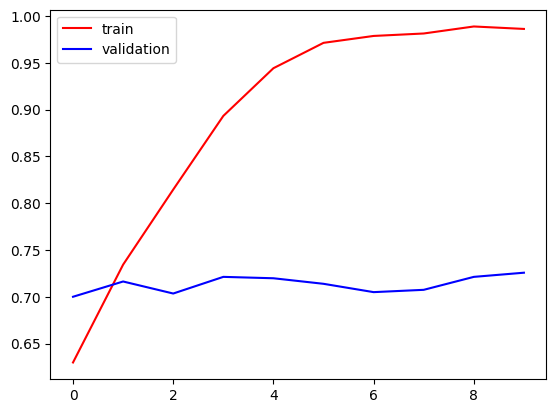

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

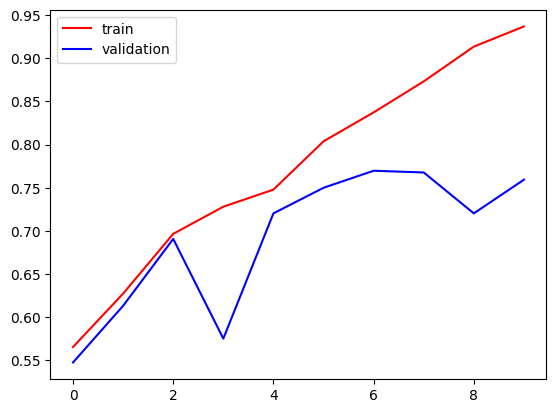

In [ ]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

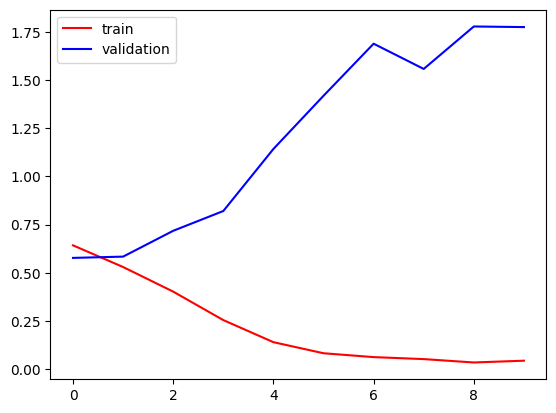

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

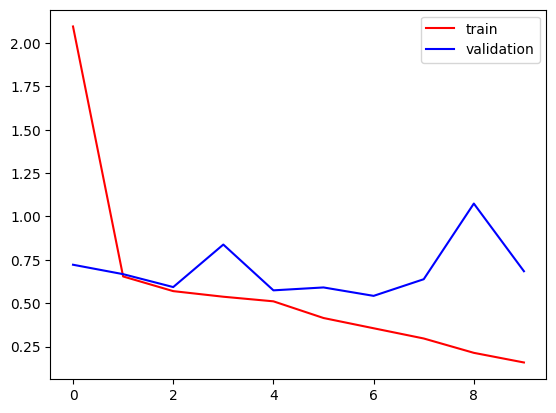

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show

In [ ]:
# way to improve overfitting

# Add more data
# Data augmentation
# L1/L2 Regulization
# Dropout
# Batch Norm
# Reduce complexity

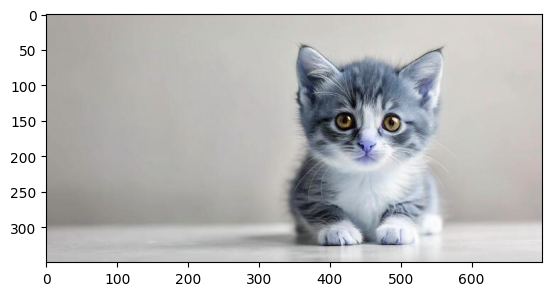

In [ ]:
import cv2 as cv
test_image=cv.imread('/content/CAT-DOG/cat image.jpg')

plt.imshow(test_image)

In [ ]:
test_image.shape

(350, 700, 3)

In [ ]:
test_image=cv.resize(test_image,(256,256))
test_image.shape

test_input=test_image.reshape((1,256,256,3))
test_input.shape

(1, 256, 256, 3)

In [ ]:
model.predict(test_input)
if model.predict(test_input)>0.5:
  print('dog')
else:
  print('cat')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
cat


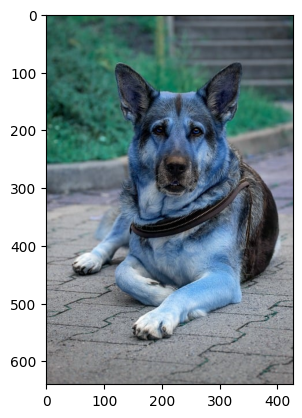

In [ ]:
test_image=cv.imread('/content/CAT-DOG/dog image.jpg')

plt.imshow(test_image)


In [ ]:
test_image=cv.resize(test_image,(256,256))

test_input=test_image.reshape((1,256,256,3))

model.predict(test_input)
if model.predict(test_input)>0.5:
  print('dog')
else:
  print('cat')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
dog
